In [1]:
import os, sys
import numpy as np
import torch

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "KAN_variants"))
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "code"))
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 1.5]

In [3]:
models = [ChebyKAN([2, 10, 2], basisOrder) for basisOrder in range(0, 10)]
kanODEs = [KANODE(model, pred_prey_deriv, X0, params, 20, 7.5, 150) for model in models]

Cheby order: 0


100%|██████████| 5000/5000 [7:49:39<00:00,  5.64s/it]  


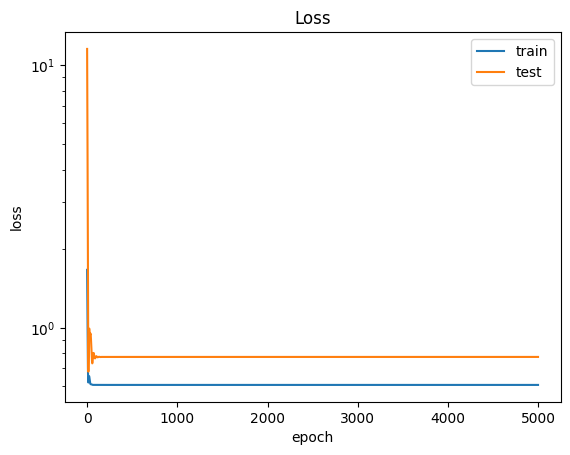

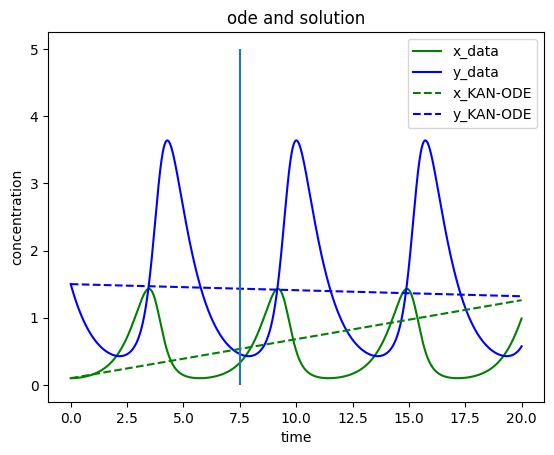

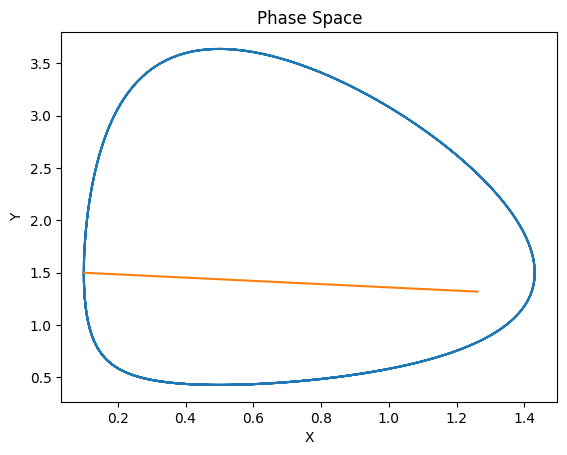

Cheby order: 1


100%|██████████| 5000/5000 [8:41:02<00:00,  6.25s/it]  


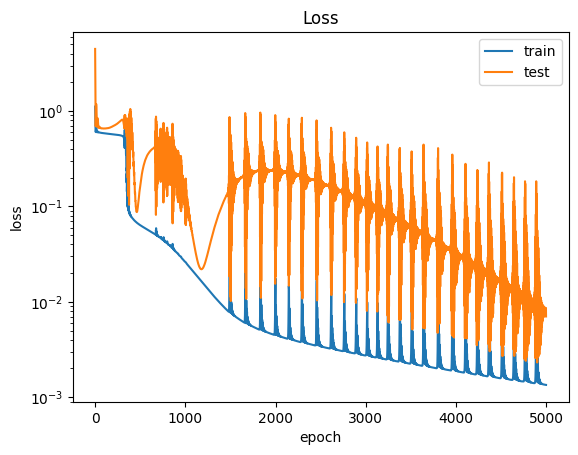

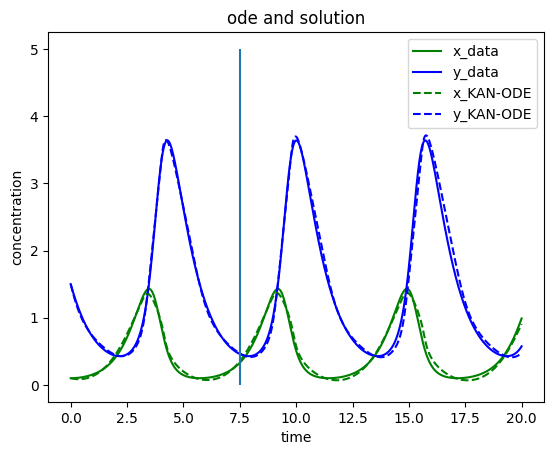

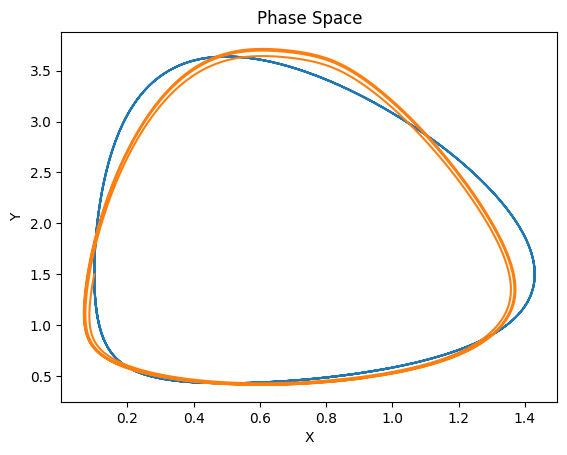

Cheby order: 2


 27%|██▋       | 1360/5000 [2:21:45<6:38:06,  6.56s/it]

In [ ]:
for kanODE in kanODEs:
    try:
        print(f"Cheby order: {kanODE.model.layers[0].degree}")
        saveDirectory = os.path.join(module_path, "savedModels", "basisOrderSweep", "rk4", f"order-{kanODE.model.layers[0].degree}")
        #os.makedirs(saveDirectory)
        kanODE.train(-1, maxEpochs=5000, saveDirectory=saveDirectory, saveCooldown=100, evalThreshold=10**-3, solverMethod="rk4")
        _, solution = kanODE.test()
        kanODE.plotLoss("Loss")
        kanODE.plotODE("ode and solution", solution[:, 0, :])
        kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])
    except:
        continue